# Marketing Hypothesis Testing

A small statistical analysis of customer profiles, household income and spending behaviour.

## tl;dr

After removing one extreme income record and imputing 24 missing income values, the analysis contains 2,239 customer records. Income and total product spending have a strong positive monotonic association (Spearman's $\rho = 0.847$, $p < 0.001$). Income distributions differ between PhD and Master's education groups (Mann–Whitney $U = 97,800.5$, $p = 0.028$), while the simplified marital-status group is not associated with education in this sample ($\chi^2 = 1.908$, $df = 4$, $p = 0.753$).

## Context and methods

The work follows a standard exploratory and non-parametric hypothesis-testing workflow. Tests use a two-sided alternative and a significance level of 0.05.

The data are a supplied customer snapshot. Results describe this dataset only and do not establish causation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.impute import KNNImputer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 180

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / 'data' / 'Marketing_data.csv'
IMAGE_DIR = PROJECT_ROOT / 'images'
ALPHA = 0.05

## Data checks

In [2]:
raw = pd.read_csv(DATA_PATH)
raw.columns = raw.columns.str.strip()

data_profile = pd.DataFrame({
    'rows': [len(raw)],
    'columns': [raw.shape[1]],
    'exact_duplicate_rows': [raw.duplicated().sum()],
    'duplicate_customer_ids': [raw['ID'].duplicated().sum()],
    'missing_income_values': [raw['Income'].isna().sum()],
})
display(data_profile)
raw.head(3)

,rows,columns,exact_duplicate_rows,duplicate_customer_ids,missing_income_values
0,2240,28,0,0,24


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US


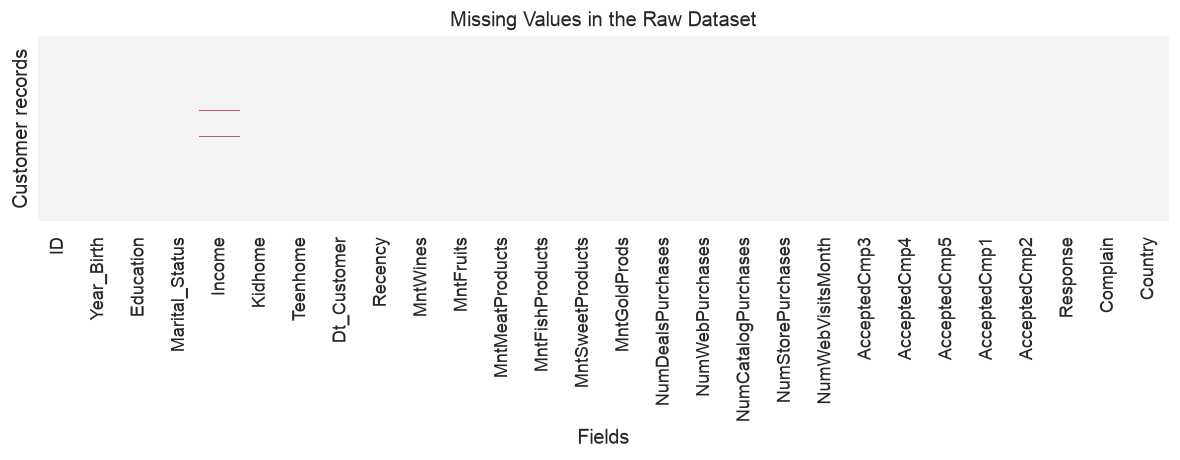

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(raw.isna(), cbar=False, yticklabels=False, cmap=['#f4f4f4', '#b15c7b'], ax=ax)
ax.set_title('Missing Values in the Raw Dataset')
ax.set_xlabel('Fields')
ax.set_ylabel('Customer records')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'missing_value_matrix.png', bbox_inches='tight')
plt.show()

/var/folders/x_/sxj4k3ld4rxcm1dw0lp6g5q80000gn/T/ipykernel_70315/4136128213.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


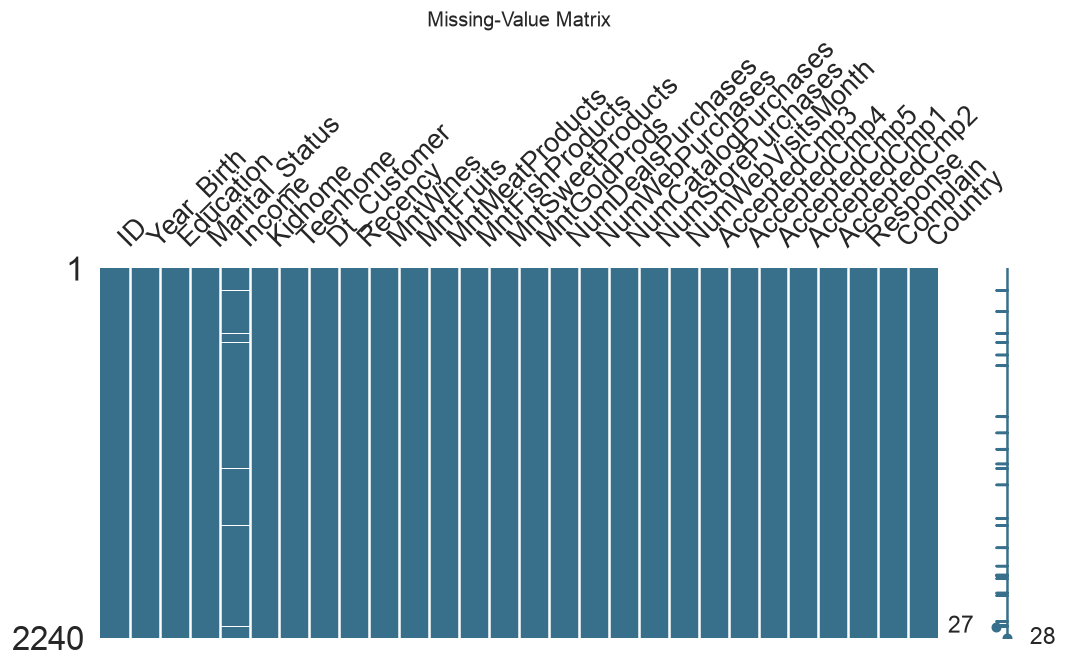

In [4]:
msno.matrix(raw, figsize=(10, 4), color=(0.22, 0.44, 0.55))
plt.title('Missing-Value Matrix')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'missingno_matrix.png', bbox_inches='tight')
plt.show()

## Prepare analysis fields

Household income is converted from its currency-text format. Total spending is the sum of the six product-spend fields. The enrolment date is parsed to calculate age at the latest observed enrolment year. Marital status is grouped into `Alone` and `In couple` for the categorical test.

,check,rows
0,"Income above 600,000",1
1,Age at enrolment above 100,3
2,Unparsed enrolment dates,0


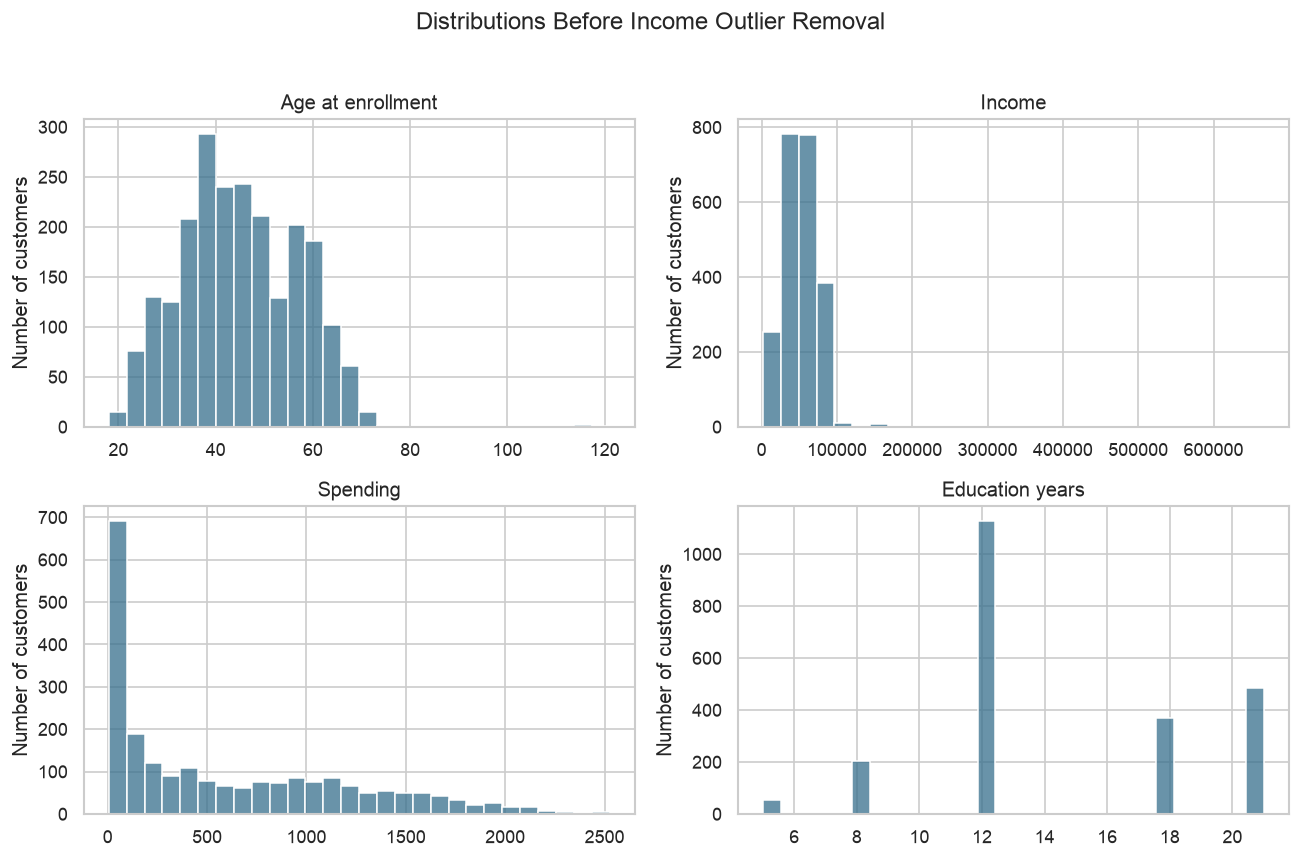

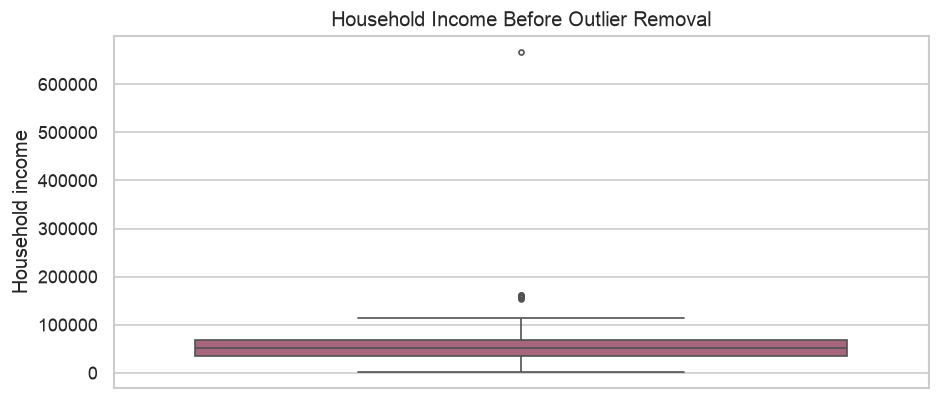

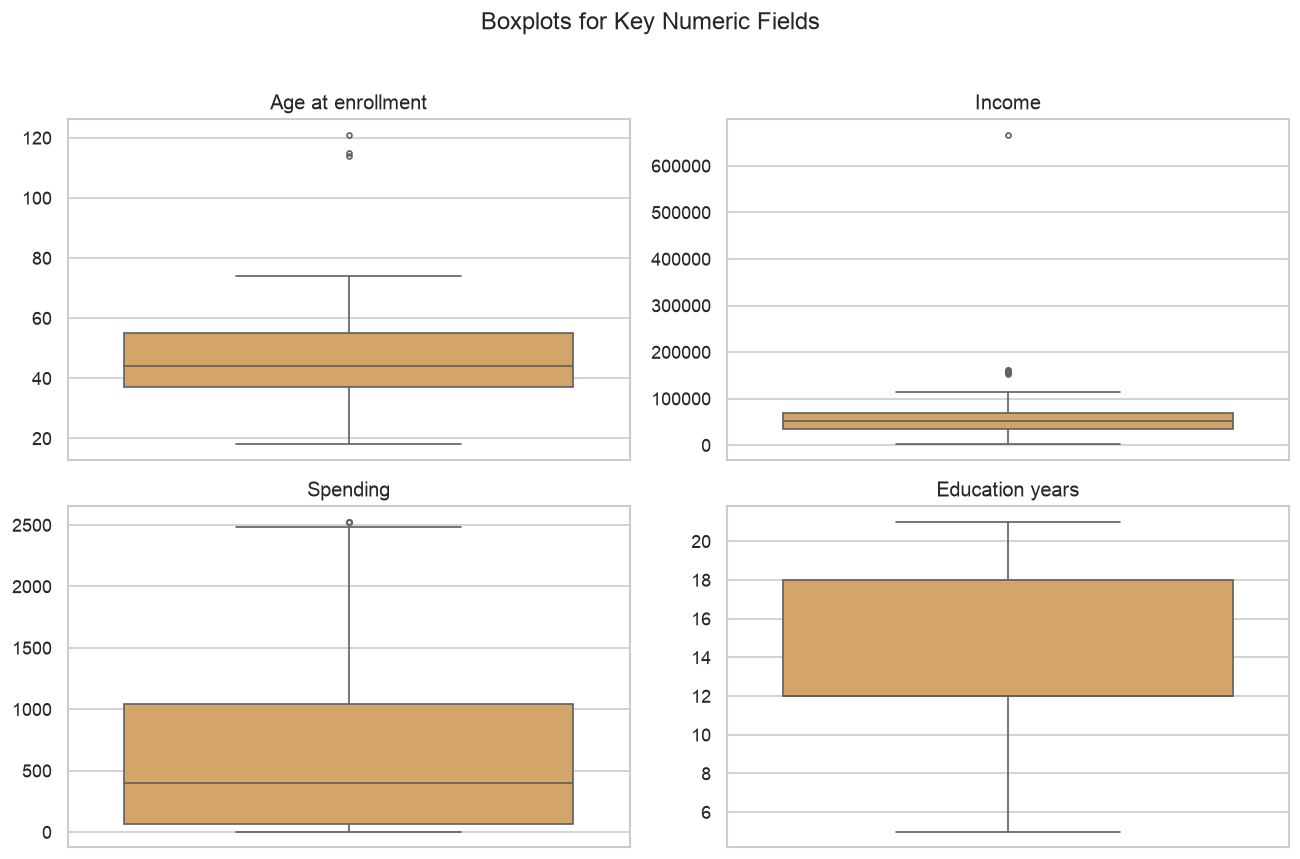

In [5]:
data = raw.copy()
data['Income'] = (
    data['Income']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%m/%d/%y', errors='coerce')
reference_year = data['Dt_Customer'].dt.year.max()
data['Age_at_enrollment'] = reference_year - data['Year_Birth']
data['Spending'] = data[[
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
]].sum(axis=1)
data['Marital_Situation'] = data['Marital_Status'].replace({
    'Divorced': 'Alone', 'Single': 'Alone', 'Widow': 'Alone',
    'Absurd': 'Alone', 'YOLO': 'Alone', 'Alone': 'Alone',
    'Married': 'In couple', 'Together': 'In couple',
})
data['Has_children'] = np.where(data['Kidhome'] + data['Teenhome'] > 0, 'Yes', 'No')
data['Education_years'] = data['Education'].map({
    'Basic': 5, '2n Cycle': 8, 'Graduation': 12, 'Master': 18, 'PhD': 21,
})

quality_flags = pd.DataFrame({
    'check': ['Income above 600,000', 'Age at enrolment above 100', 'Unparsed enrolment dates'],
    'rows': [
        data['Income'].gt(600000).sum(),
        data['Age_at_enrollment'].gt(100).sum(),
        data['Dt_Customer'].isna().sum(),
    ],
})
display(quality_flags)

overview_fields = ['Age_at_enrollment', 'Income', 'Spending', 'Education_years']
overview = data[overview_fields].melt(var_name='field', value_name='value')

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, field in zip(axes.flat, overview_fields):
    sns.histplot(data=data, x=field, bins=28, color='#376f8c', edgecolor='white', ax=ax)
    ax.set_title(field.replace('_', ' '))
    ax.set_xlabel('')
    ax.set_ylabel('Number of customers')
fig.suptitle('Distributions Before Income Outlier Removal', y=1.02)
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'key_variable_distributions.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.boxplot(y=data['Income'], color='#b15c7b', fliersize=3, ax=ax)
ax.set_title('Household Income Before Outlier Removal')
ax.set_xlabel('')
ax.set_ylabel('Household income')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'income_boxplot_before_outlier_removal.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, field in zip(axes.flat, overview_fields):
    sns.boxplot(y=data[field], color='#e6a756', fliersize=3, ax=ax)
    ax.set_title(field.replace('_', ' '))
    ax.set_xlabel('')
    ax.set_ylabel('')
fig.suptitle('Boxplots for Key Numeric Fields', y=1.02)
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'key_variable_boxplots.png', bbox_inches='tight')
plt.show()

In [6]:
plotly_boxplots = px.box(
    overview, y='value', facet_col='field', facet_col_wrap=2,
    color='field', height=800,
    title='Outlier Review for Key Numeric Fields'
)
plotly_boxplots.update_yaxes(matches=None, showticklabels=True)
plotly_boxplots.update_layout(showlegend=False)
plotly_boxplots.show()

## Handle one extreme income value and missing income

One income value above 600,000 is removed before imputation. Missing income values are then imputed using five nearest neighbours based on income, age at enrolment and education years. Three unusually high ages are retained because they are not one of the tested outcomes; they should be validated against the original source before operational use.

In [7]:
analysis = data.loc[~data['Income'].gt(600000)].copy().reset_index(drop=True)

imputer = KNNImputer(n_neighbors=5, metric='nan_euclidean')
imputed_fields = imputer.fit_transform(
    analysis[['Income', 'Age_at_enrollment', 'Education_years']]
)
analysis[['Income', 'Age_at_enrollment', 'Education_years']] = imputed_fields

post_cleaning = pd.DataFrame({
    'rows_after_preparation': [len(analysis)],
    'missing_values_after_preparation': [int(analysis.isna().sum().sum())],
    'duplicate_customer_ids_after_preparation': [analysis['ID'].duplicated().sum()],
})
display(post_cleaning)

,rows_after_preparation,missing_values_after_preparation,duplicate_customer_ids_after_preparation
0,2239,0,0


## Descriptive views

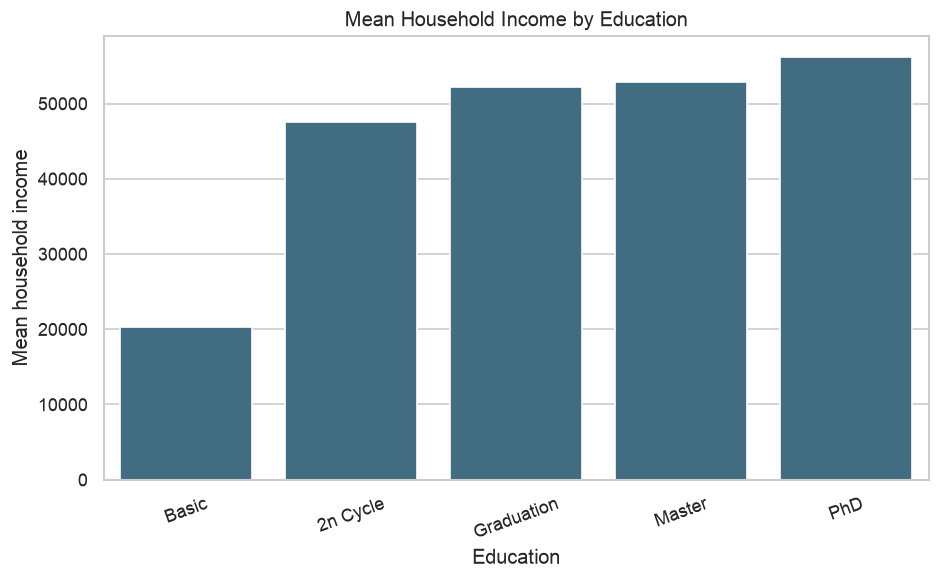

In [8]:
education_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']
income_by_education = (
    analysis.groupby('Education', observed=True)['Income']
    .mean()
    .reindex(education_order)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=income_by_education.index, y=income_by_education.values, color='#376f8c', ax=ax)
ax.set_title('Mean Household Income by Education')
ax.set_xlabel('Education')
ax.set_ylabel('Mean household income')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'mean_income_by_education.png', bbox_inches='tight')
plt.show()

In [9]:
plotly_income_by_education = px.histogram(
    analysis, x='Education', y='Income', histfunc='avg',
    category_orders={'Education': education_order},
    title='Mean Household Income by Education'
)
plotly_income_by_education.show()

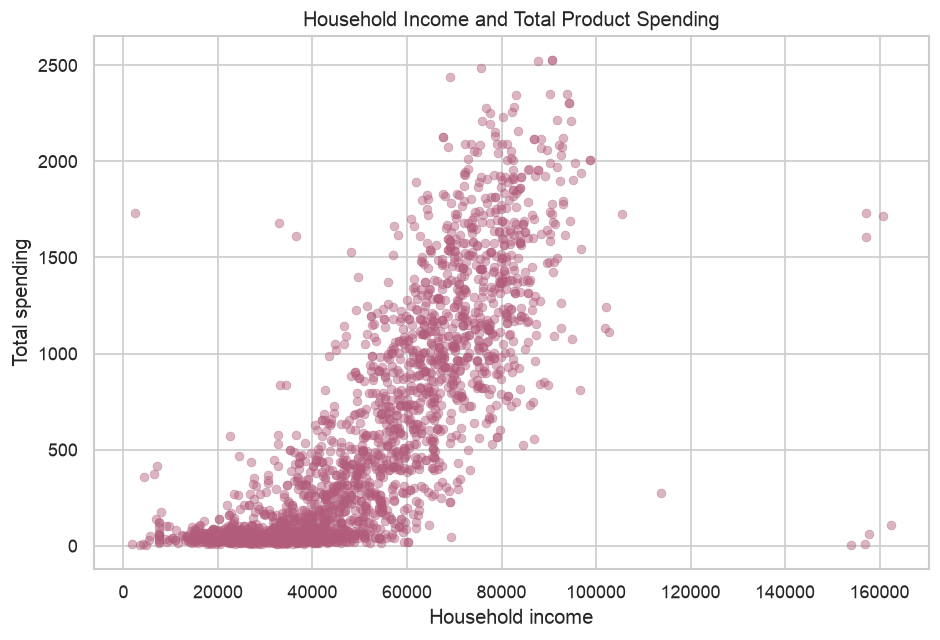

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=analysis, x='Income', y='Spending', alpha=0.45, s=28, color='#b15c7b', edgecolor=None, ax=ax)
ax.set_title('Household Income and Total Product Spending')
ax.set_xlabel('Household income')
ax.set_ylabel('Total spending')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'income_and_spending.png', bbox_inches='tight')
plt.show()

In [11]:
plotly_income_spending = go.Figure(data=go.Scatter(
    x=analysis['Spending'], y=analysis['Income'], mode='markers',
    marker={'color': '#b15c7b', 'opacity': 0.55}, name='Customers'
))
plotly_income_spending.update_layout(
    title='Total Product Spending and Household Income',
    xaxis_title='Total spending', yaxis_title='Household income'
)
plotly_income_spending.show()

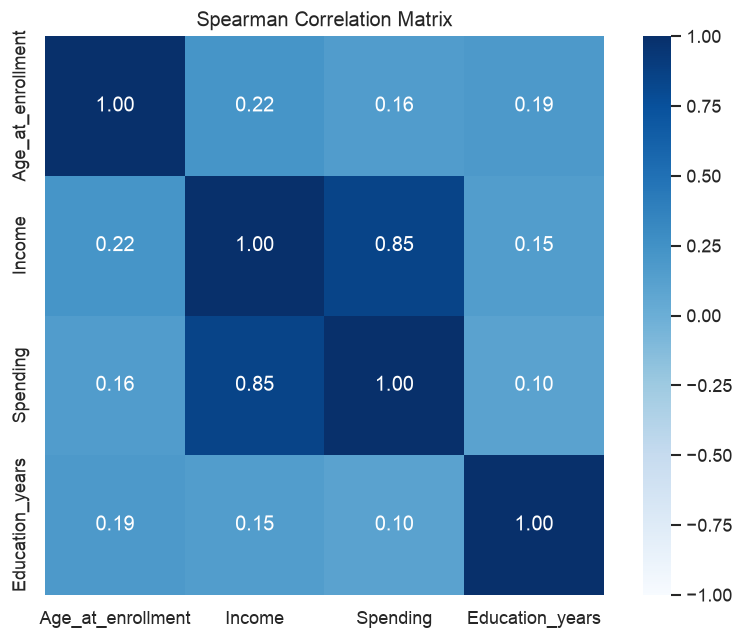

In [12]:
numeric_fields = ['Age_at_enrollment', 'Income', 'Spending', 'Education_years']
correlation = analysis[numeric_fields].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(correlation, cmap='Blues', vmin=-1, vmax=1, center=0, annot=True, fmt='.2f', square=True, ax=ax)
ax.set_title('Spearman Correlation Matrix')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'spearman_correlation_matrix.png', bbox_inches='tight')
plt.show()

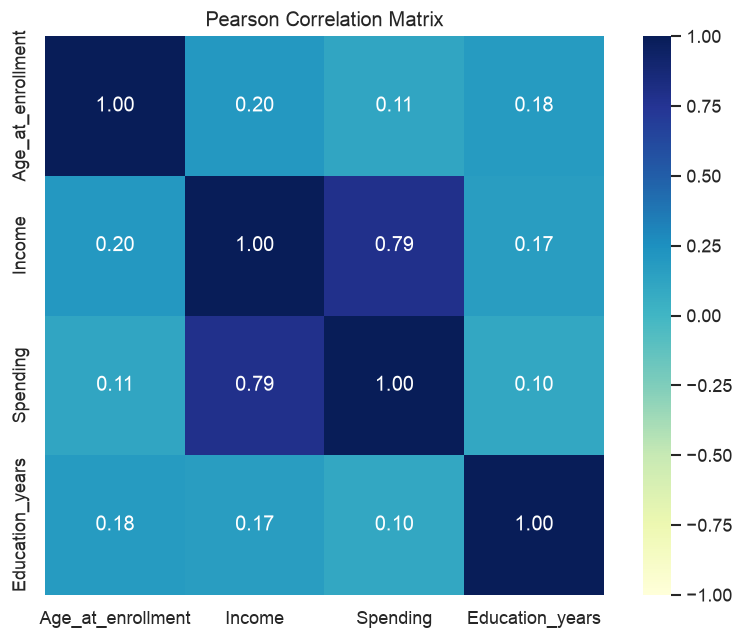

In [13]:
pearson_correlation = analysis[numeric_fields].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(pearson_correlation, cmap='YlGnBu', vmin=-1, vmax=1, center=0, annot=True, fmt='.2f', square=True, ax=ax)
ax.set_title('Pearson Correlation Matrix')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'pearson_correlation_matrix.png', bbox_inches='tight')
plt.show()

/var/folders/x_/sxj4k3ld4rxcm1dw0lp6g5q80000gn/T/ipykernel_70315/4160400157.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis, x='Has_children', y='Income', order=['Yes', 'No'], palette={'Yes': '#376f8c', 'No': '#e6a756'}, ax=axes[1])


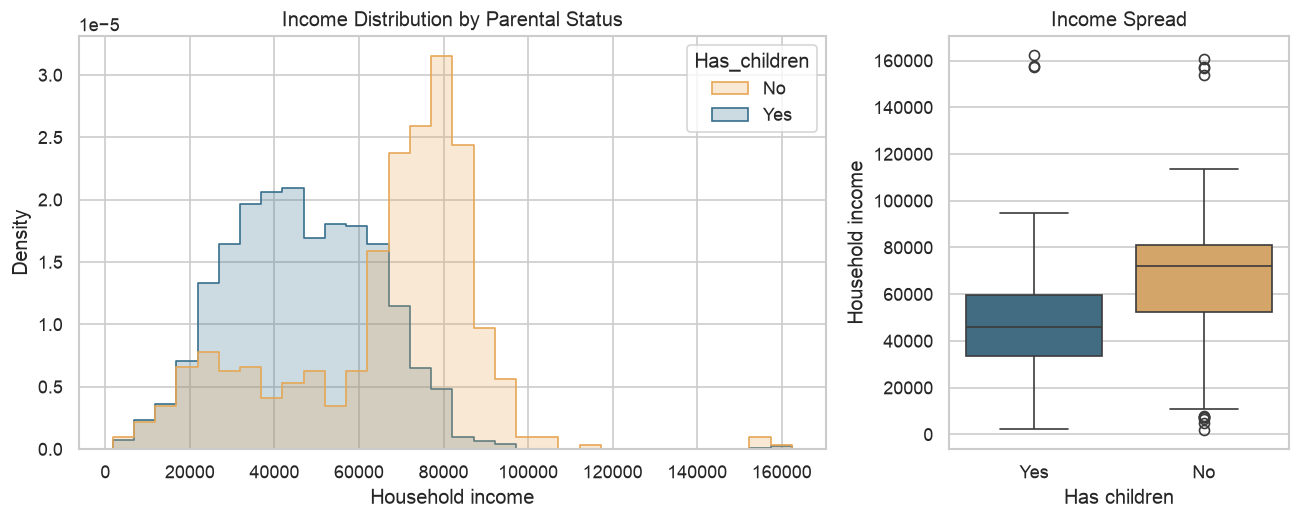

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [2.2, 1]})
sns.histplot(
    data=analysis, x='Income', hue='Has_children', bins=32,
    stat='density', common_norm=False, element='step', fill=True,
    palette={'Yes': '#376f8c', 'No': '#e6a756'}, ax=axes[0]
)
axes[0].set_title('Income Distribution by Parental Status')
axes[0].set_xlabel('Household income')
axes[0].set_ylabel('Density')
sns.boxplot(data=analysis, x='Has_children', y='Income', order=['Yes', 'No'], palette={'Yes': '#376f8c', 'No': '#e6a756'}, ax=axes[1])
axes[1].set_title('Income Spread')
axes[1].set_xlabel('Has children')
axes[1].set_ylabel('Household income')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'income_by_parental_status.png', bbox_inches='tight')
plt.show()

In [15]:
plotly_income_by_parental_status = px.histogram(
    analysis, x='Income', marginal='box', color='Has_children',
    color_discrete_map={'Yes': '#376f8c', 'No': '#e6a756'},
    title='Income Level by Parental Status'
)
plotly_income_by_parental_status.update_layout(bargap=0.1)
plotly_income_by_parental_status.show()

## Distribution check

Shapiro–Wilk tests are used as a distribution check. Since the variables tested here have p-values below 0.05, the following comparisons use non-parametric tests.

In [16]:
normality_rows = []
for column in ['Age_at_enrollment', 'Income', 'Spending', 'Education_years']:
    statistic, p_value = stats.shapiro(analysis[column])
    normality_rows.append({
        'variable': column,
        'statistic': statistic,
        'p_value': p_value,
        'normal_at_0_05': p_value > ALPHA,
    })
normality_results = pd.DataFrame(normality_rows)
display(normality_results.round({'statistic': 3, 'p_value': 6}))

,variable,statistic,p_value,normal_at_0_05
0,Age_at_enrollment,0.976,0.0,False
1,Income,0.976,0.0,False
2,Spending,0.865,0.0,False
3,Education_years,0.833,0.0,False


## Test 1: PhD and Master's income distributions

**Null hypothesis:** the two groups have equal income distributions.  
**Alternative hypothesis:** the income distributions differ.

In [17]:
phd_income = analysis.loc[analysis['Education'].eq('PhD'), 'Income']
master_income = analysis.loc[analysis['Education'].eq('Master'), 'Income']
mann_whitney_u, mann_whitney_p = stats.mannwhitneyu(
    phd_income, master_income, alternative='two-sided'
)

income_test = pd.DataFrame({
    'PhD sample size': [len(phd_income)],
    "Master's sample size": [len(master_income)],
    'PhD median income': [phd_income.median()],
    "Master's median income": [master_income.median()],
    'Mann–Whitney U': [mann_whitney_u],
    'p_value': [mann_whitney_p],
    'decision_at_0_05': ['Reject the null hypothesis' if mann_whitney_p <= ALPHA else 'Fail to reject the null hypothesis'],
})
display(income_test.round({
    'PhD median income': 0, "Master's median income": 0,
    'Mann–Whitney U': 1, 'p_value': 6,
}))

,PhD sample size,Master's sample size,PhD median income,Master's median income,Mann–Whitney U,p_value,decision_at_0_05
0,486,370,55212.0,50943.0,97800.5,0.027686,Reject the null hypothesis


## Test 2: income and spending

**Null hypothesis:** income and spending have no monotonic association.  
**Alternative hypothesis:** income and spending have a monotonic association.

In [18]:
spearman_rho, spearman_p = stats.spearmanr(analysis['Income'], analysis['Spending'])
correlation_test = pd.DataFrame({
    "Spearman's rho": [spearman_rho],
    'p_value': [spearman_p],
    'decision_at_0_05': ['Reject the null hypothesis' if spearman_p <= ALPHA else 'Fail to reject the null hypothesis'],
})
display(correlation_test.round({"Spearman's rho": 4, 'p_value': 6}))

,Spearman's rho,p_value,decision_at_0_05
0,0.8466,0.0,Reject the null hypothesis


## Test 3: education and marital-status group

**Null hypothesis:** education and the simplified marital-status group are independent.  
**Alternative hypothesis:** the variables are associated.

Marital_Situation,Alone,In couple
Education,,
2n Cycle,65,138
Basic,20,34
Graduation,408,718
Master,126,244
PhD,177,309


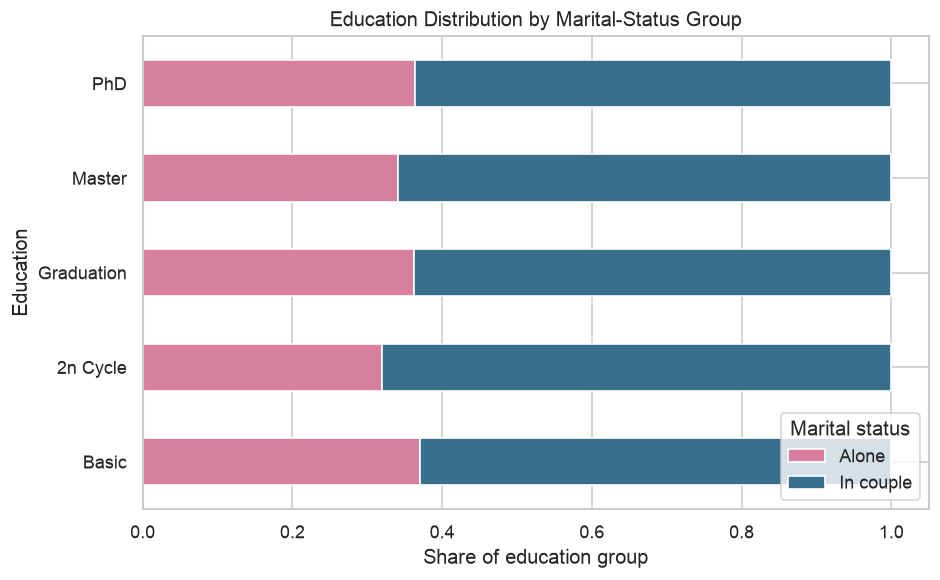

,chi_square,degrees_of_freedom,p_value,decision_at_0_05
0,1.908,4,0.752606,Fail to reject the null hypothesis


In [19]:
education_marital_table = pd.crosstab(analysis['Education'], analysis['Marital_Situation'])
chi_square, chi_p_value, degrees_of_freedom, expected = stats.chi2_contingency(education_marital_table)
display(education_marital_table)

education_marital_share = education_marital_table.div(education_marital_table.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(8, 5))
education_marital_share.loc[['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']].plot(
    kind='barh', stacked=True, color=['#d67f9f', '#376f8c'], ax=ax
)
ax.set_title('Education Distribution by Marital-Status Group')
ax.set_xlabel('Share of education group')
ax.set_ylabel('Education')
ax.legend(title='Marital status', loc='lower right')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'education_by_marital_status.png', bbox_inches='tight')
plt.show()

plotly_education_marital = px.sunburst(
    analysis, path=['Marital_Situation', 'Education'],
    title='Education Distribution by Marital-Status Group'
)
plotly_education_marital.show()

chi_square_test = pd.DataFrame({
    'chi_square': [chi_square],
    'degrees_of_freedom': [degrees_of_freedom],
    'p_value': [chi_p_value],
    'decision_at_0_05': ['Reject the null hypothesis' if chi_p_value <= ALPHA else 'Fail to reject the null hypothesis'],
})
display(chi_square_test.round({'chi_square': 3, 'p_value': 6}))

## Takeaways

- The income–spending relationship is strongly positive in rank terms, but this is an association rather than evidence of causation.
- The PhD and Master's groups differ in household-income distribution in this sample. The Mann–Whitney result compares distributions; it does not prove an education effect.
- There is no statistical evidence here of an association between education and the simplified marital-status group.
- The dataset includes three implausibly old ages at enrolment. They are retained for reproducibility but should be checked against source records before use in a customer-facing or operational analysis.